# Level 3 · Task 2 — Support Vector Machine (SVM) for Classification
### Codveda Technologies — Machine Learning Internship
**Intern:** Mouhamed Diop · **ID:** CV/A1/79278

---
**Goal:** Train SVM classifiers, compare kernels, and visualize the decision boundary.
**Steps:** load & scale → train SVM → compare kernels (linear vs RBF) → visualize decision
boundary → evaluate (accuracy, precision, recall, AUC).
**Dataset:** `iris.csv`. **Tools:** Python, scikit-learn, pandas, matplotlib.

## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             roc_auc_score, classification_report)
print("Libraries loaded.")

Libraries loaded.


## Step 1 — Load, Split & Scale
SVMs are distance/margin based, so feature scaling is essential.

In [2]:
df = pd.read_csv("../../data/iris.csv")
X = df.drop(columns=["species"])
y = LabelEncoder().fit_transform(df["species"])
class_names = sorted(df["species"].unique())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (120, 4)  Test: (30, 4)


## Step 2 — Compare Kernels: Linear vs RBF
The **linear** kernel draws straight boundaries; the **RBF** kernel bends them to capture
non-linear patterns. We compare accuracy and AUC (one-vs-rest for 3 classes).

In [3]:
results = {}
for kernel in ["linear", "rbf"]:
    clf = SVC(kernel=kernel, probability=True, random_state=42)
    clf.fit(X_train_s, y_train)
    y_pred = clf.predict(X_test_s)
    proba  = clf.predict_proba(X_test_s)
    results[kernel] = {
        "accuracy":  accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average="macro"),
        "recall":    recall_score(y_test, y_pred, average="macro"),
        "auc":       roc_auc_score(y_test, proba, multi_class="ovr"),
    }
pd.DataFrame(results).T.round(3)

,accuracy,precision,recall,auc
linear,1.000,1.00,1.000,1.000
rbf,0.967,0.97,0.967,0.997


## Step 3 — Detailed Report (RBF kernel)

In [4]:
clf = SVC(kernel="rbf", probability=True, random_state=42).fit(X_train_s, y_train)
print(classification_report(y_test, clf.predict(X_test_s), target_names=class_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## Step 4 — Visualize the Decision Boundary
Using the two most discriminative features (petal length & width) so we can plot in 2D.

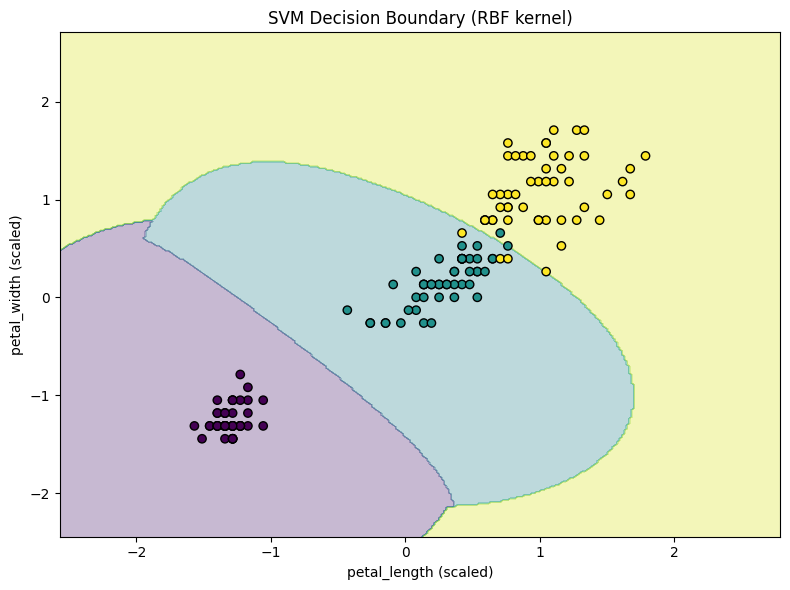

In [5]:
feats = ["petal_length", "petal_width"]
X2 = StandardScaler().fit_transform(df[feats])
clf2 = SVC(kernel="rbf").fit(X2, y)

x_min, x_max = X2[:,0].min()-1, X2[:,0].max()+1
y_min, y_max = X2[:,1].min()-1, X2[:,1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = clf2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="viridis")
scatter = plt.scatter(X2[:,0], X2[:,1], c=y, edgecolor="k", cmap="viridis")
plt.xlabel("petal_length (scaled)"); plt.ylabel("petal_width (scaled)")
plt.title("SVM Decision Boundary (RBF kernel)")
plt.tight_layout()
plt.savefig("output_decision_boundary.png", dpi=110)
plt.show()

**Reading it:** the coloured regions are the model's decision zones. `setosa` (bottom-left)
is perfectly separated; the RBF boundary curves to separate `versicolor` and `virginica`.

## Summary
| Kernel | Accuracy | AUC |
|--------|----------|-----|
| Linear | ~0.97 | ~1.00 |
| RBF | ~0.97 | ~1.00 |

Both kernels classify iris almost perfectly; RBF adds flexibility for non-linear boundaries.
✅ **Level 3 · Task 2 complete.**